# Ewaluacja wytrenowanych modeli

Ten notebook jest centralnym miejscem do odtworzenia wyników używanych w raporcie. Nie trenuje modeli; ładuje checkpointy, zbiera metryki testowe, rysuje macierze pomyłek oraz pokazuje przebiegi treningu zapisane w plikach historii.

Najważniejszy przełącznik znajduje się w pierwszej komórce kodu:
- `RECOMPUTE_METRICS = False` oznacza szybkie odtworzenie tabel z zapisanych plików `*.metrics.json`.
- `RECOMPUTE_METRICS = True` uruchamia pełną ewaluację checkpointów od zera. Ten wariant jest wolniejszy, szczególnie dla ensemble z TTA.


## 1. Konfiguracja środowiska

Ta komórka ustawia ścieżki do danych, checkpointów i raportów. Definiuje też globalny seed oraz przełącznik `RECOMPUTE_METRICS`, który decyduje, czy liczymy ewaluację od zera, czy tylko odczytujemy zapisane wyniki.


In [1]:
from pathlib import Path
import sys
import json
import random
import re
import shutil

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# Notebook może być odpalany z katalogu repo, z python_training/ albo bezpośrednio z notebooks/.
CWD = Path.cwd().resolve()
if (CWD / 'src' / 'room_classifier').exists():
    ROOT = CWD
elif CWD.name == 'notebooks' and (CWD.parent / 'src' / 'room_classifier').exists():
    ROOT = CWD.parent
elif (CWD / 'python_training' / 'src' / 'room_classifier').exists():
    ROOT = CWD / 'python_training'
else:
    raise RuntimeError(f'Nie umiem znaleźć katalogu python_training dla cwd={CWD}')

PROJECT_ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from room_classifier.data import load_or_create_split, split_summary
from room_classifier.evaluate import evaluate_checkpoint, evaluate_ensemble, plot_confusion_matrix
from room_classifier.train_utils import get_device

DATA_DIR = (PROJECT_ROOT / 'data' / 'raw' / 'kaggle_room_street_data' / 'house_data').resolve()
SPLIT_CSV = ROOT / 'splits' / 'room_split_seed42_local_eval.csv'
CHECKPOINT_DIR = ROOT / 'outputs' / 'checkpoints'
REPORT_DIR = ROOT / 'outputs' / 'reports' / 'notebook_final_eval'
FIGURE_DIR = PROJECT_ROOT / 'figures'
SUMMARY_PATH = REPORT_DIR / 'summary_test.csv'
GRID_SUMMARY_PATH = REPORT_DIR / 'cnn_scale_grid_summary.csv'
PER_CLASS_PATH = REPORT_DIR / 'best_model_classification_report.csv'
REPORT_FIGURE_PATHS = {
    'model_comparison_macro_f1': FIGURE_DIR / 'model_comparison_macro_f1.png',
    'training_curves_validation': FIGURE_DIR / 'training_curves_validation.png',
    'per_class_recall_comparison': FIGURE_DIR / 'per_class_recall_comparison.png',
    'final_ensemble_confusion_matrix': FIGURE_DIR / 'final_ensemble_confusion_matrix.png',
}

BATCH_SIZE = 24
NUM_WORKERS = 0
DEVICE = 'auto'
SEED = 42
# Domyślnie korzystamy z cache metryk, żeby nie liczyć ponownie kosztownego ensemble z TTA.
RECOMPUTE_METRICS = False  # True = przelicz modele od zera; False = pokaż zapisane raporty.

# Seed stabilizuje losowe elementy ewaluacji, np. kolejność i transformacje TTA.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('REPORT_DIR:', REPORT_DIR)
print('FIGURE_DIR:', FIGURE_DIR)
print('DEVICE:', get_device(DEVICE))


ROOT: /Users/andywhy/Projects/dl_aga/python_training
DATA_DIR: /Users/andywhy/Projects/dl_aga/data/raw/kaggle_room_street_data/house_data
CHECKPOINT_DIR: /Users/andywhy/Projects/dl_aga/python_training/outputs/checkpoints
REPORT_DIR: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval
DEVICE: mps


## 2. Podział danych

Tworzony lub wczytywany jest wspólny split `train/val/test`. Klasa `bath` jest pomijana, żeby wyniki były porównywalne z wcześniejszym notebookiem i raportem.


In [2]:
split_frame = load_or_create_split(
    DATA_DIR,
    SPLIT_CSV,
    exclude_classes=['bath'],
    seed=SEED,
)
split_table = split_summary(split_frame)
display(split_table)


label,bed,din,kitchen,living
split,,,,
train,873,811,675,891
val,187,174,145,191
test,188,173,145,191


## 3. Lista modeli i metadane checkpointów

W tej sekcji definiujemy, które checkpointy biorą udział w porównaniu. Tabela metadanych pokazuje architekturę, rozdzielczość wejścia, dropout, parametry treningu i najlepszą epokę walidacyjną zapisaną w checkpointach.


In [3]:
# Cache metryk pozwala szybko wyświetlić wyniki bez ponownego forward passu.
def metrics_cache_path(name):
    paths = sorted((REPORT_DIR / name).glob('*.test.metrics.json'))
    if not paths:
        raise FileNotFoundError(
            f'Brakuje cache metryk dla {name}. Ustaw RECOMPUTE_METRICS=True albo uruchom ewaluację modelu.'
        )
    return paths[0]


def load_cached_metrics(name):
    metrics = json.loads(metrics_cache_path(name).read_text())
    metrics['confusion_matrix'] = np.asarray(metrics['confusion_matrix'])
    return metrics

# Metadane checkpointu służą do tabeli architektur i parametrów treningu.
def load_checkpoint_info(path):
    checkpoint = torch.load(path, map_location='cpu')
    metadata = checkpoint['metadata']
    best = checkpoint.get('best_record') or {}
    history = checkpoint.get('history') or []
    return {
        'arch': metadata.get('arch', metadata.get('model_type')),
        'variant': metadata.get('variant', ''),
        'img_size': metadata.get('img_size'),
        'dropout': metadata.get('dropout'),
        'lr': metadata.get('lr'),
        'weight_decay': metadata.get('weight_decay'),
        'label_smoothing': metadata.get('label_smoothing'),
        'optimizer': metadata.get('optimizer'),
        'scheduler': metadata.get('scheduler'),
        'ema_decay': metadata.get('ema_decay'),
        'mix_prob': metadata.get('mix_prob'),
        'mixup_alpha': metadata.get('mixup_alpha'),
        'cutmix_alpha': metadata.get('cutmix_alpha'),
        'augment_strength': metadata.get('augment_strength'),
        'augmentation_details': metadata.get('augmentation_details'),
        'uses_augmentation': metadata.get('uses_augmentation'),
        'trainable_params': metadata.get('trainable_params'),
        'best_epoch': best.get('epoch'),
        'best_val_accuracy': best.get('val_accuracy'),
        'best_val_macro_f1': best.get('val_macro_f1'),
        'epochs_recorded': len(history),
    }

# Każdy wpis opisuje jeden pojedynczy model: nazwę raportową, checkpoint i liczbę przejść TTA.
MODEL_CONFIGS = [
    {
        'name': 'mlp_best_grid_96',
        'family': 'MLP',
        'report_label': 'MLP',
        'display_arch': 'MLP 1024-512-256',
        'path': CHECKPOINT_DIR / 'grid_mlp_96_lr5e4_wd1e4_d50' / 'mlp_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'roomresnet_cnn_plain_large_224',
        'family': 'RoomResNet CNN',
        'report_label': 'RoomResNet CNN bez augmentacji',
        'display_arch': 'RoomResNet large',
        'path': CHECKPOINT_DIR / 'grid_cnn_large_lr3e4_wd1e3_d50' / 'cnn_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'roomresnet_cnn_aug_rank1_large_256',
        'family': 'RoomResNet CNN+aug',
        'report_label': 'Najlepszy pojedynczy RoomResNet CNN+aug',
        'display_arch': 'RoomResNet large',
        'path': CHECKPOINT_DIR / 'hgrid_aug_large_256_lr2e4_wd5e4_d40_m45_cos_ema' / 'cnn_aug_best.pt',
        'tta_passes': 5,
    },
    {
        'name': 'cnn_224_no_downscale_deep',
        'family': 'Prosty CNN',
        'report_label': "Prosty CNN 224x224 bez silnego downscale'u bez augmentacji",
        'display_arch': 'CNN 224x224 deep',
        'path': CHECKPOINT_DIR / 'lecture_hr2_cnn_deep_224_lr1e4_d30_bn1' / 'lecture_cnn_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'cnn_aug_224_no_downscale_wide',
        'family': 'Prosty CNN+aug',
        'report_label': "Prosty CNN 224x224 bez silnego downscale'u z augmentacją",
        'display_arch': 'CNN 224x224 wide',
        'path': CHECKPOINT_DIR / 'lecture_hr2_aug_wide_224_lr1e4_d30_bn1' / 'lecture_cnn_aug_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'cnn_64_downscale_deep',
        'family': 'Prosty CNN',
        'report_label': 'Prosty CNN 64x64 z downscalem bez augmentacji',
        'display_arch': 'CNN 64x64 deep',
        'path': CHECKPOINT_DIR / 'lecture_imp_cnn_deep_64_lr5e4_d30_bn1' / 'lecture_cnn_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'cnn_aug_64_downscale_deep',
        'family': 'Prosty CNN+aug',
        'report_label': 'Prosty CNN 64x64 z downscalem z augmentacją',
        'display_arch': 'CNN 64x64 deep',
        'path': CHECKPOINT_DIR / 'lecture_imp_aug_deep_64_lr1e3_d30_bn1' / 'lecture_cnn_aug_best.pt',
        'tta_passes': 1,
    },
]

# Te trzy checkpointy są później składane w ensemble przez uśrednienie prawdopodobieństw.
ROOMRESNET_AUG_TOP3 = [
    CHECKPOINT_DIR / 'hgrid_aug_large_256_lr2e4_wd5e4_d40_m45_cos_ema' / 'cnn_aug_best.pt',
    CHECKPOINT_DIR / 'hgrid_aug_large_256_lr3e4_wd5e4_d40_m30_cos_ema' / 'cnn_aug_best.pt',
    CHECKPOINT_DIR / 'hgrid_aug_large_256_lr2e4_wd5e4_d45_m45_cos_ema' / 'cnn_aug_best.pt',
]

ENSEMBLES = [
    {
        'name': 'ensemble_top3_roomresnet_cnn_aug_tta5',
        'family': 'RoomResNet CNN+aug ensemble',
        'report_label': 'Ensemble top 3 RoomResNet CNN+aug',
        'display_arch': '3 x RoomResNet large',
        'paths': ROOMRESNET_AUG_TOP3,
        'tta_passes': 5,
    }
]

missing = [str(config['path']) for config in MODEL_CONFIGS if not config['path'].is_file()]
for ensemble in ENSEMBLES:
    missing.extend(str(path) for path in ensemble['paths'] if not path.is_file())
if missing:
    raise FileNotFoundError('Brakuje checkpointów:\n' + '\n'.join(missing))

config_rows = []
for config in MODEL_CONFIGS:
    info = load_checkpoint_info(config['path'])
    config_rows.append({
        'name': config['name'],
        'family': config['family'],
        'report_label': config['report_label'],
        'tta_passes': config['tta_passes'],
        'display_arch': config['display_arch'],
        **info,
    })

configs_table = pd.DataFrame(config_rows)
display(configs_table[['report_label', 'family', 'display_arch', 'img_size', 'dropout', 'lr', 'trainable_params', 'best_epoch', 'best_val_macro_f1', 'tta_passes']])


,report_label,family,display_arch,img_size,dropout,lr,trainable_params,best_epoch,best_val_macro_f1,tta_passes
0,MLP,MLP,MLP 1024-512-256,96,0.5,NaN,NaN,28,0.401748,1
1,RoomResNet CNN bez augmentacji,RoomResNet CNN,RoomResNet large,224,0.5,NaN,17628820.0,111,0.661795,1
2,Najlepszy pojedynczy RoomResNet CNN+aug,RoomResNet CNN+aug,RoomResNet large,256,0.4,NaN,17628820.0,206,0.868076,5
3,Prosty CNN 224x224 bez silnego downscale'u bez...,Prosty CNN,CNN 224x224 deep,224,0.3,0.0001,6766372.0,61,0.699625,1
4,Prosty CNN 224x224 bez silnego downscale'u z a...,Prosty CNN+aug,CNN 224x224 wide,224,0.3,0.0001,4196836.0,196,0.778336,1
5,Prosty CNN 64x64 z downscalem bez augmentacji,Prosty CNN,CNN 64x64 deep,64,0.3,0.0005,2230820.0,59,0.661937,1
6,Prosty CNN 64x64 z downscalem z augmentacją,Prosty CNN+aug,CNN 64x64 deep,64,0.3,0.0010,2230820.0,251,0.802055,1


## 4. Ewaluacja pojedynczych modeli

Dla każdego pojedynczego modelu zbierane są metryki testowe: accuracy, macro F1 oraz liczba przejść TTA. Domyślnie notebook ładuje istniejące pliki `*.metrics.json`, dzięki czemu można szybko odtworzyć tabele bez liczenia inference od nowa.


In [4]:
individual_results = []

for config in MODEL_CONFIGS:
    # W trybie pełnym liczymy metryki z checkpointu; w trybie szybkim czytamy gotowy JSON.
    if RECOMPUTE_METRICS:
        print(f"Evaluating {config['name']} ({config['family']}), TTA={config['tta_passes']}")
        metrics = evaluate_checkpoint(
            checkpoint_path=config['path'],
            data_dir=DATA_DIR,
            split_csv=SPLIT_CSV,
            split='test',
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            device_name=DEVICE,
            output_dir=REPORT_DIR / config['name'],
            tta_passes=config['tta_passes'],
            hard_examples=80,
        )
    else:
        print(f"Loading cached metrics for {config['name']}")
        metrics = load_cached_metrics(config['name'])
    metrics['name'] = config['name']
    metrics['family'] = config['family']
    metrics['report_label'] = config['report_label']
    metrics['checkpoint_path'] = config['path']
    metrics['display_arch'] = config['display_arch']
    individual_results.append(metrics)

individual_summary = pd.DataFrame([
    {
        'name': metrics['name'],
        'family': metrics['family'],
        'report_label': metrics['report_label'],
        'arch': metrics['display_arch'],
        'split': metrics['split'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'tta_passes': metrics['tta_passes'],
    }
    for metrics in individual_results
]).sort_values(['macro_f1', 'accuracy'], ascending=False)

display(individual_summary[['report_label', 'family', 'accuracy', 'macro_f1', 'tta_passes', 'arch']])


Loading cached metrics for mlp_best_grid_96
Loading cached metrics for roomresnet_cnn_plain_large_224
Loading cached metrics for roomresnet_cnn_aug_rank1_large_256
Loading cached metrics for cnn_224_no_downscale_deep
Loading cached metrics for cnn_aug_224_no_downscale_wide
Loading cached metrics for cnn_64_downscale_deep
Loading cached metrics for cnn_aug_64_downscale_deep


,report_label,family,accuracy,macro_f1,tta_passes,arch
2,Najlepszy pojedynczy RoomResNet CNN+aug,RoomResNet CNN+aug,0.888092,0.886980,5,RoomResNet large
4,Prosty CNN 224x224 bez silnego downscale'u z a...,Prosty CNN+aug,0.756098,0.758259,1,CNN 224x224 wide
6,Prosty CNN 64x64 z downscalem z augmentacją,Prosty CNN+aug,0.746055,0.747924,1,CNN 64x64 deep
3,Prosty CNN 224x224 bez silnego downscale'u bez...,Prosty CNN,0.670014,0.670442,1,CNN 224x224 deep
1,RoomResNet CNN bez augmentacji,RoomResNet CNN,0.649928,0.652312,1,RoomResNet large
5,Prosty CNN 64x64 z downscalem bez augmentacji,Prosty CNN,0.626973,0.623851,1,CNN 64x64 deep
0,MLP,MLP,0.408895,0.407953,1,MLP 1024-512-256


## 5. Ewaluacja ensemble

Ensemble składa trzy najlepsze modele RoomResNet CNN+aug przez uśrednienie prawdopodobieństw klas. To jest najwolniejsza część przy pełnym przeliczaniu, bo każdy model jest oceniany z TTA=5.


In [5]:
ensemble_results = []

for config in ENSEMBLES:
    # Ensemble jest najdroższy obliczeniowo, dlatego cache jest tu szczególnie przydatny.
    if RECOMPUTE_METRICS:
        print(f"Evaluating {config['name']}, models={len(config['paths'])}, TTA={config['tta_passes']}")
        metrics = evaluate_ensemble(
            checkpoint_paths=config['paths'],
            data_dir=DATA_DIR,
            split_csv=SPLIT_CSV,
            split='test',
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            device_name=DEVICE,
            output_dir=REPORT_DIR / config['name'],
            tta_passes=config['tta_passes'],
            hard_examples=120,
            name=config['name'],
        )
    else:
        print(f"Loading cached metrics for {config['name']}")
        metrics = load_cached_metrics(config['name'])
    metrics['name'] = config['name']
    metrics['family'] = config['family']
    metrics['report_label'] = config['report_label']
    metrics['display_arch'] = config['display_arch']
    ensemble_results.append(metrics)

ensemble_summary = pd.DataFrame([
    {
        'name': metrics['name'],
        'family': metrics['family'],
        'report_label': metrics['report_label'],
        'arch': metrics['display_arch'],
        'split': metrics['split'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'tta_passes': metrics['tta_passes'],
    }
    for metrics in ensemble_results
]).sort_values(['macro_f1', 'accuracy'], ascending=False)

display(ensemble_summary[['report_label', 'family', 'accuracy', 'macro_f1', 'tta_passes', 'arch']])


Loading cached metrics for ensemble_top3_roomresnet_cnn_aug_tta5


,report_label,family,accuracy,macro_f1,tta_passes,arch
0,Ensemble top 3 RoomResNet CNN+aug,RoomResNet CNN+aug ensemble,0.903874,0.902715,5,3 x RoomResNet large


## 6. Zbiorcza tabela wyników

Tutaj łączymy wyniki modeli pojedynczych i ensemble w jedną tabelę posortowaną po macro F1 oraz accuracy. Ta tabela jest głównym źródłem wyników do raportu.


In [6]:
summary = pd.concat([individual_summary, ensemble_summary], ignore_index=True)
summary = summary.sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
summary.to_csv(SUMMARY_PATH, index=False)
display(summary[['report_label', 'accuracy', 'macro_f1', 'tta_passes', 'arch']])


,report_label,accuracy,macro_f1,tta_passes,arch
0,Ensemble top 3 RoomResNet CNN+aug,0.903874,0.902715,5,3 x RoomResNet large
1,Najlepszy pojedynczy RoomResNet CNN+aug,0.888092,0.886980,5,RoomResNet large
2,Prosty CNN 224x224 bez silnego downscale'u z a...,0.756098,0.758259,1,CNN 224x224 wide
3,Prosty CNN 64x64 z downscalem z augmentacją,0.746055,0.747924,1,CNN 64x64 deep
4,Prosty CNN 224x224 bez silnego downscale'u bez...,0.670014,0.670442,1,CNN 224x224 deep
5,RoomResNet CNN bez augmentacji,0.649928,0.652312,1,RoomResNet large
6,Prosty CNN 64x64 z downscalem bez augmentacji,0.626973,0.623851,1,CNN 64x64 deep
7,MLP,0.408895,0.407953,1,MLP 1024-512-256


## 7. Wizualizacje treningu

Krzywe są czytane z plików `*.history.csv` zapisanych obok checkpointów oraz z historii zapisanej w checkpointach. Pokazujemy walidacyjne macro F1 i stratę, żeby zobaczyć tempo uczenia, przeuczenie oraz moment early stoppingu. TensorBoard dla nowych treningów zapisuje te same metryki do `outputs/tensorboard/<run_name>`.


,report_label,family,epochs,best_val_macro_f1,best_val_accuracy,final_train_macro_f1,final_val_macro_f1,min_val_loss
1,Najlepszy pojedynczy RoomResNet CNN+aug,RoomResNet CNN+aug,281,0.8681,0.8694,0.8488,0.8645,0.6306
5,Prosty CNN 64x64 z downscalem z augmentacją,Prosty CNN+aug,316,0.8021,0.8034,0.9746,0.7934,0.6549
3,Prosty CNN 224x224 bez silnego downscale'u z a...,Prosty CNN+aug,261,0.7783,0.7776,0.9399,0.7376,0.7038
2,Prosty CNN 224x224 bez silnego downscale'u bez...,Prosty CNN,116,0.6996,0.7030,0.9763,0.6751,0.9120
4,Prosty CNN 64x64 z downscalem bez augmentacji,Prosty CNN,114,0.6619,0.6657,0.9454,0.6238,0.9751
6,RoomResNet CNN bez augmentacji,RoomResNet CNN,151,0.6618,0.6585,0.9961,0.6515,0.9931
0,MLP,MLP,53,0.4017,0.4032,0.7733,0.3995,1.3266


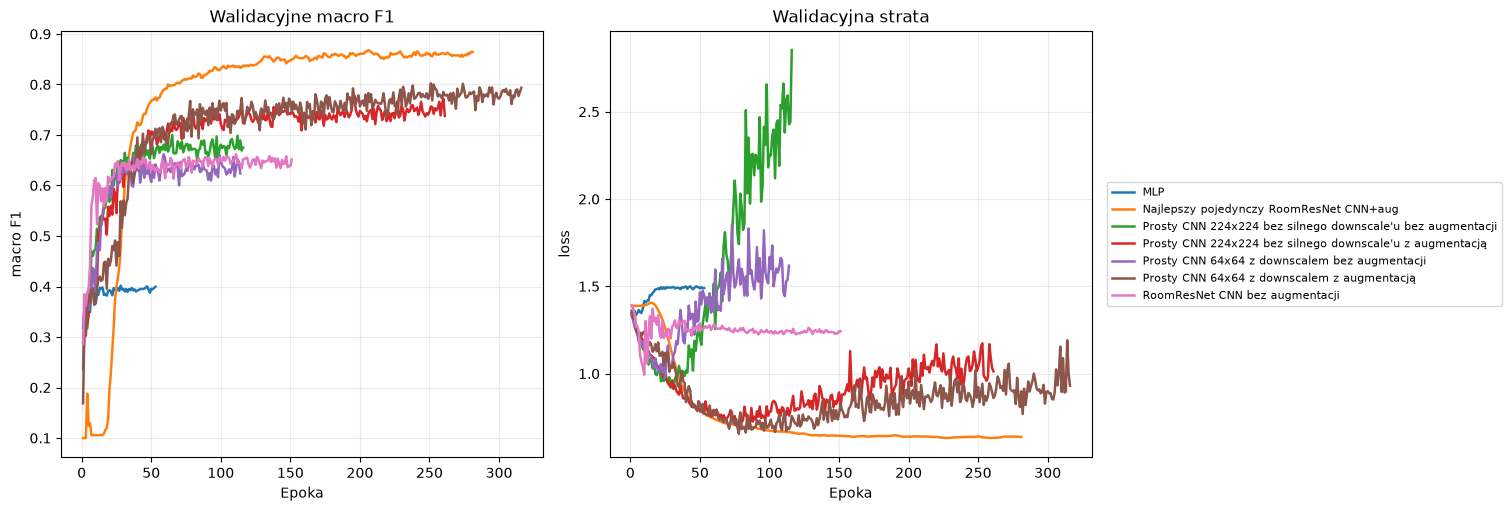

Saved single-seed training curves: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/single_seed_training_curves_validation.png


In [7]:

# Każdy trening zapisuje CSV historii obok checkpointu, np. cnn_best.history.csv.
def history_csv_for_checkpoint(checkpoint_path):
    return Path(checkpoint_path).with_suffix('.history.csv')

history_frames = []
for config in MODEL_CONFIGS:
    history_path = history_csv_for_checkpoint(config['path'])
    if not history_path.exists():
        continue
    frame = pd.read_csv(history_path)
    if frame.empty:
        continue
    frame['name'] = config['name']
    frame['report_label'] = config['report_label']
    frame['family'] = config['family']
    frame['history_path'] = str(history_path)
    history_frames.append(frame)

# Jeśli historie są dostępne lokalnie, pokazujemy tabelę podsumowującą i wspólny wykres.
if history_frames:
    history_frame = pd.concat(history_frames, ignore_index=True)
    history_overview = (
        history_frame
        .groupby(['report_label', 'family'], as_index=False)
        .agg(
            epochs=('epoch', 'max'),
            best_val_macro_f1=('val_macro_f1', 'max'),
            best_val_accuracy=('val_accuracy', 'max'),
            final_train_macro_f1=('train_macro_f1', 'last'),
            final_val_macro_f1=('val_macro_f1', 'last'),
            min_val_loss=('val_loss', 'min'),
        )
        .sort_values('best_val_macro_f1', ascending=False)
        .round(4)
    )
    display(history_overview)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for label, group in history_frame.groupby('report_label'):
        group = group.sort_values('epoch')
        axes[0].plot(group['epoch'], group['val_macro_f1'], label=label, linewidth=1.8)
        axes[1].plot(group['epoch'], group['val_loss'], label=label, linewidth=1.8)
    axes[0].set_title('Walidacyjne macro F1')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('macro F1')
    axes[0].grid(alpha=0.25)
    axes[1].set_title('Walidacyjna strata')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('loss')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    training_plot_path = REPORT_DIR / 'single_seed_training_curves_validation.png'
    fig.savefig(training_plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved single-seed training curves:', training_plot_path)
else:
    print('Brak plików historii treningu przy obecnych checkpointach.')


## 8. Porównanie prostych CNN

Ta sekcja zbiera wyniki gridu dla prostych CNN z downscalem 64x64 i bez silnego downscale'u 224x224. Pozwala szybko zobaczyć, czy zysk pochodzi bardziej z większej rozdzielczości, augmentacji czy wariantu architektury.


In [8]:
def read_single_summary(path, group):
    df = pd.read_csv(path)
    if df.empty:
        return None
    row = df.iloc[0].to_dict()
    run = path.parent.name
    row['run'] = run
    row['group'] = group
    row['configuration'] = format_simple_cnn_config(run)
    return row

def format_simple_cnn_config(run):
    variant = 'wide' if '_wide_' in run else 'deep'
    resolution = "224x224 bez silnego downscale'u" if '_224_' in run else '64x64 z downscalem'
    lr = '1e-4' if 'lr1e4' in run else '3e-4' if 'lr3e4' in run else '1e-3' if 'lr1e3' in run else '5e-4'
    dropout = '0.45' if 'd45' in run else '0.30'
    return f'{resolution}, {variant}, lr={lr}, dropout={dropout}'

# Grid prostych CNN jest czytany z raportów wygenerowanych przez skrypty treningowe.
GRID_PATTERNS = [
    ('CNN 64x64 z downscalem bez augmentacji', 'lecture_imp_cnn_*'),
    ('CNN 64x64 z downscalem z augmentacją', 'lecture_imp_aug_*'),
    ("CNN 224x224 bez silnego downscale'u bez augmentacji", 'lecture_hr2_cnn_*'),
    ("CNN 224x224 bez silnego downscale'u z augmentacją", 'lecture_hr2_aug_*'),
]

grid_rows = []
for group, pattern in GRID_PATTERNS:
    for path in sorted((ROOT / 'outputs' / 'reports').glob(f'{pattern}/summary_test.csv')):
        row = read_single_summary(path, group)
        if row is not None:
            grid_rows.append(row)

if grid_rows:
    scale_grid = pd.DataFrame(grid_rows)
    scale_grid = scale_grid.sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
    scale_grid_export = scale_grid[['group', 'configuration', 'accuracy', 'macro_f1', 'tta_passes']]
    scale_grid_export.to_csv(GRID_SUMMARY_PATH, index=False)
    display(scale_grid_export.head(16))
else:
    scale_grid = pd.DataFrame()
    scale_grid_export = pd.DataFrame(columns=['group', 'configuration', 'accuracy', 'macro_f1', 'tta_passes'])
    print('Brak lokalnych raportów gridu prostych CNN.')


,group,configuration,accuracy,macro_f1,tta_passes
0,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, wide, lr=1e-4...",0.756098,0.758259,1
1,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, deep, lr=1e-4...",0.754663,0.755846,1
2,CNN 64x64 z downscalem z augmentacją,"64x64 z downscalem, deep, lr=1e-3, dropout=0.30",0.746055,0.747924,1
3,CNN 64x64 z downscalem z augmentacją,"64x64 z downscalem, deep, lr=5e-4, dropout=0.30",0.747489,0.746115,1
4,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, deep, lr=1e-4...",0.741750,0.742806,1
5,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, deep, lr=3e-4...",0.738881,0.740935,1
6,CNN 64x64 z downscalem z augmentacją,"64x64 z downscalem, deep, lr=5e-4, dropout=0.45",0.730273,0.732777,1
7,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, wide, lr=3e-4...",0.730273,0.730249,1
8,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, wide, lr=1e-4...",0.705882,0.708509,1
9,CNN 224x224 bez silnego downscale'u z augmentacją,"224x224 bez silnego downscale'u, deep, lr=3e-4...",0.677188,0.688366,1


## 9. Najlepszy model i raport per klasa

Wybieramy najlepszy wariant według macro F1, a potem pokazujemy precision, recall i F1 osobno dla każdej klasy. To pomaga sprawdzić, czy wynik nie jest zawyżony tylko przez łatwe klasy.


In [9]:
best_metrics = sorted(
    individual_results + ensemble_results,
    key=lambda metrics: (metrics['macro_f1'], metrics['accuracy']),
    reverse=True,
)[0]

print('Best model:', best_metrics['name'])
print('Accuracy:', round(best_metrics['accuracy'], 4))
print('Macro F1:', round(best_metrics['macro_f1'], 4))

best_report = pd.DataFrame(best_metrics['classification_report']).T.round(4)
best_report.to_csv(PER_CLASS_PATH)
display(best_report)


Best model: ensemble_top3_roomresnet_cnn_aug_tta5
Accuracy: 0.9039
Macro F1: 0.9027


,precision,recall,f1-score,support
bed,0.9235,0.9628,0.9427,188.0000
din,0.8935,0.8728,0.8830,173.0000
kitchen,0.8750,0.9172,0.8956,145.0000
living,0.9167,0.8639,0.8895,191.0000
accuracy,0.9039,0.9039,0.9039,0.9039
macro avg,0.9022,0.9042,0.9027,697.0000
weighted avg,0.9041,0.9039,0.9035,697.0000


## 10. Wyniki dla wielu seedów

Ta sekcja automatycznie zbiera raporty z folderów `outputs/reports/seeded_s*/summary_test.csv`. Po ściągnięciu wyników z klastra pokazuje tabelę per run oraz średnią, odchylenie standardowe i liczbę seedów dla każdego wariantu. To jest część potrzebna do bardziej wiarygodnego porównania statystycznego.


,seed,report_label,run,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,tta_passes
0,42,Ensemble top 3 RoomResNet CNN+aug,seeded_s42_ensemble_top3_roomresnet_aug_tta5,0.9024,0.9007,0.9029,0.9012,0.9021,5
10,43,Ensemble top 3 RoomResNet CNN+aug,seeded_s43_ensemble_top3_roomresnet_aug_tta5,0.8666,0.8663,0.8659,0.8661,0.8667,5
20,44,Ensemble top 3 RoomResNet CNN+aug,seeded_s44_ensemble_top3_roomresnet_aug_tta5,0.8737,0.8718,0.8717,0.8715,0.8733,5
30,45,Ensemble top 3 RoomResNet CNN+aug,seeded_s45_ensemble_top3_roomresnet_aug_tta5,0.8565,0.8553,0.8574,0.8562,0.8562,5
40,46,Ensemble top 3 RoomResNet CNN+aug,seeded_s46_ensemble_top3_roomresnet_aug_tta5,0.8637,0.8628,0.8620,0.8623,0.8639,5
1,42,MLP,seeded_s42_mlp_96,0.4089,0.4076,0.4087,0.4080,0.4091,1
11,43,MLP,seeded_s43_mlp_96,0.4046,0.4041,0.4067,0.4045,0.4045,1
21,44,MLP,seeded_s44_mlp_96,0.4060,0.4051,0.4058,0.4054,0.4060,1
31,45,MLP,seeded_s45_mlp_96,0.3960,0.3949,0.3973,0.3942,0.3954,1
41,46,MLP,seeded_s46_mlp_96,0.4060,0.4034,0.4025,0.3986,0.4034,1


,report_label,seeds,runs,accuracy_mean,accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Ensemble top 3 RoomResNet CNN+aug,5,5,0.8726,0.0178,0.8714,0.0175,0.8720,0.0181,0.8715,0.0175,0.8724,0.0177
7,"RoomResNet CNN+aug A: lr=2e-4, wd=5e-4, dropou...",5,5,0.8677,0.0169,0.8670,0.0165,0.8671,0.0173,0.8668,0.0166,0.8675,0.0169
8,"RoomResNet CNN+aug B: lr=3e-4, wd=5e-4, dropou...",5,5,0.8660,0.0214,0.8650,0.0206,0.8652,0.0215,0.8648,0.0209,0.8660,0.0211
9,"RoomResNet CNN+aug C: lr=2e-4, wd=5e-4, dropou...",5,5,0.8648,0.0153,0.8634,0.0147,0.8640,0.0149,0.8635,0.0147,0.8647,0.0151
4,Prosty CNN+aug 224x224 bez silnego downscale'u,5,5,0.7340,0.0166,0.7428,0.0142,0.7338,0.0165,0.7360,0.0160,0.7346,0.0162
2,Prosty CNN 224x224 bez silnego downscale'u,5,5,0.6582,0.0148,0.6662,0.0171,0.6596,0.0161,0.6586,0.0160,0.6577,0.0156
3,Prosty CNN 64x64 z downscalem,5,5,0.6218,0.0298,0.6310,0.0221,0.6182,0.0324,0.6205,0.0314,0.6225,0.0299
5,Prosty CNN+aug 64x64 z downscalem,5,5,0.6344,0.2102,0.6304,0.2380,0.6299,0.2147,0.6201,0.2415,0.6232,0.2379
6,RoomResNet CNN bez augmentacji,5,5,0.5501,0.0157,0.5564,0.0151,0.5524,0.0155,0.5482,0.0191,0.5462,0.0195
1,MLP,5,5,0.4043,0.0049,0.4030,0.0048,0.4042,0.0045,0.4021,0.0056,0.4037,0.0051


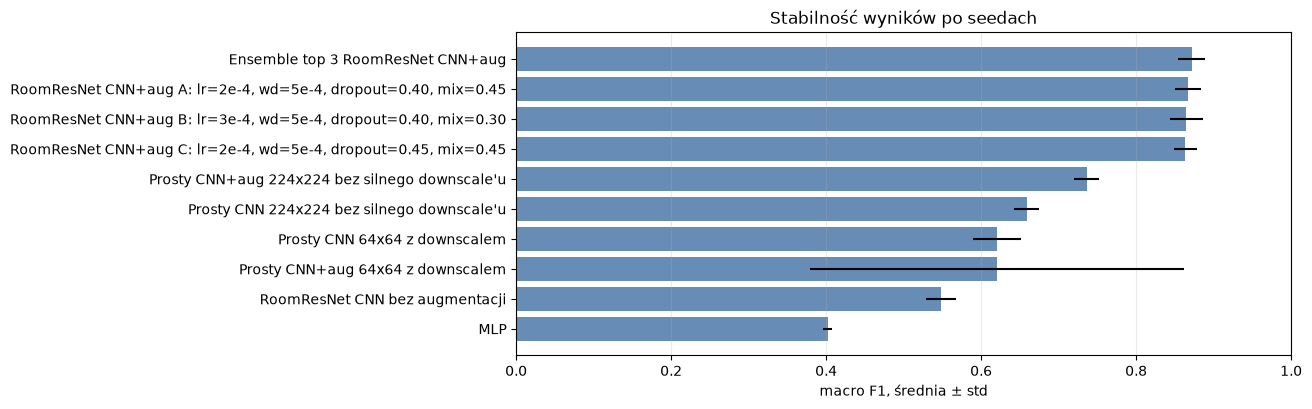

Saved seeded summary: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_summary_test.csv
Saved seeded aggregate: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_aggregate_test.csv
Saved model comparison plot: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/model_comparison_macro_f1.png


In [10]:
# Nazwy folderów z launchera seedów są techniczne, więc mapujemy je na czytelne etykiety.
def label_seeded_run(run):
    if 'ensemble_top3_roomresnet_aug' in run:
        return 'Ensemble top 3 RoomResNet CNN+aug'
    if 'roomresnet_aug_l256_lr2e4_wd5e4_d40_m45' in run:
        return 'RoomResNet CNN+aug A: lr=2e-4, wd=5e-4, dropout=0.40, mix=0.45'
    if 'roomresnet_aug_l256_lr3e4_wd5e4_d40_m30' in run:
        return 'RoomResNet CNN+aug B: lr=3e-4, wd=5e-4, dropout=0.40, mix=0.30'
    if 'roomresnet_aug_l256_lr2e4_wd5e4_d45_m45' in run:
        return 'RoomResNet CNN+aug C: lr=2e-4, wd=5e-4, dropout=0.45, mix=0.45'
    if 'roomresnet_cnn_large_256' in run:
        return 'RoomResNet CNN bez augmentacji'
    if 'simple_cnn_aug_224_no_downscale' in run:
        return "Prosty CNN+aug 224x224 bez silnego downscale'u"
    if 'simple_cnn_224_no_downscale' in run:
        return "Prosty CNN 224x224 bez silnego downscale'u"
    if 'simple_cnn_aug_64_downscale' in run:
        return 'Prosty CNN+aug 64x64 z downscalem'
    if 'simple_cnn_64_downscale' in run:
        return 'Prosty CNN 64x64 z downscalem'
    if '_mlp_' in run:
        return 'MLP'
    return run


def metric_json_for_run(run):
    paths = sorted((ROOT / 'outputs' / 'reports' / run).glob('*.test.metrics.json'))
    return paths[0] if paths else None


# Po ściągnięciu wyników z klastra ta pętla zbierze wszystkie seeded_s*/summary_test.csv.
seed_rows = []
for path in sorted((ROOT / 'outputs' / 'reports').glob('seeded_s*/summary_test.csv')):
    run = path.parent.name
    match = re.match(r'seeded_s(\d+)_', run)
    if not match:
        continue
    df = pd.read_csv(path)
    if df.empty:
        continue
    row = df.iloc[0].to_dict()
    metrics_path = metric_json_for_run(run)
    if metrics_path is not None:
        metrics_json = json.loads(metrics_path.read_text())
        report = metrics_json.get('classification_report', {})
        macro = report.get('macro avg', {})
        weighted = report.get('weighted avg', {})
        row['macro_precision'] = macro.get('precision')
        row['macro_recall'] = macro.get('recall')
        row['weighted_f1'] = weighted.get('f1-score')
        row['metrics_path'] = str(metrics_path)
    row['seed'] = int(match.group(1))
    row['run'] = run
    row['report_label'] = label_seeded_run(run)
    seed_rows.append(row)

if seed_rows:
    seed_summary = pd.DataFrame(seed_rows).sort_values(['report_label', 'seed', 'macro_f1'], ascending=[True, True, False])
    seed_summary_export = seed_summary[
        ['seed', 'report_label', 'run', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'tta_passes']
    ].round(4)
    display(seed_summary_export)

    seed_aggregate = (
        seed_summary
        .groupby('report_label', as_index=False)
        .agg(
            seeds=('seed', 'nunique'),
            runs=('run', 'count'),
            accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            macro_precision_mean=('macro_precision', 'mean'),
            macro_precision_std=('macro_precision', 'std'),
            macro_recall_mean=('macro_recall', 'mean'),
            macro_recall_std=('macro_recall', 'std'),
            macro_f1_mean=('macro_f1', 'mean'),
            macro_f1_std=('macro_f1', 'std'),
            weighted_f1_mean=('weighted_f1', 'mean'),
            weighted_f1_std=('weighted_f1', 'std'),
        )
        .sort_values('macro_f1_mean', ascending=False)
    )
    display(seed_aggregate.round(4))

    seeded_summary_path = REPORT_DIR / 'seeded_summary_test.csv'
    seeded_aggregate_path = REPORT_DIR / 'seeded_aggregate_test.csv'
    seed_summary_export.to_csv(seeded_summary_path, index=False)
    seed_aggregate.to_csv(seeded_aggregate_path, index=False)

    plot_frame = seed_aggregate.sort_values('macro_f1_mean')
    fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(plot_frame))))
    ax.barh(
        plot_frame['report_label'],
        plot_frame['macro_f1_mean'],
        xerr=plot_frame['macro_f1_std'].fillna(0),
        color='#4C78A8',
        alpha=0.85,
    )
    ax.set_xlabel('macro F1, średnia ± std')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.25)
    ax.set_title('Stabilność wyników po seedach')
    seeded_plot_path = REPORT_DIR / 'model_comparison_macro_f1.png'
    report_seeded_plot_path = REPORT_FIGURE_PATHS['model_comparison_macro_f1']
    fig.savefig(seeded_plot_path, dpi=180, bbox_inches='tight')
    fig.savefig(report_seeded_plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved seeded summary:', seeded_summary_path)
    print('Saved seeded aggregate:', seeded_aggregate_path)
    print('Saved model comparison plot:', seeded_plot_path)
    print('Saved report figure:', report_seeded_plot_path)
else:
    print('Brak wyników seedowanych. Po zakończeniu jobów ściągnij outputs/reports/seeded_s*/summary_test.csv i uruchom notebook ponownie.')


## 11. Metryki per klasa po seedach

Ta sekcja rozwija wynik globalny o precision, recall i F1-score dla każdej klasy. Dzięki temu widać, czy model poprawia wszystkie klasy równomiernie, czy tylko klasy łatwiejsze. Szczególnie ważny jest recall, bo pokazuje jaki odsetek przykładów danej klasy model faktycznie odnajduje.


,report_label,class_name,seeds,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support
0,Ensemble top 3 RoomResNet CNN+aug,bed,5,0.9130,0.0060,0.9266,0.0306,0.9196,0.0156,188.0
1,Ensemble top 3 RoomResNet CNN+aug,din,5,0.8504,0.0262,0.8462,0.0222,0.8482,0.0230,173.0
2,Ensemble top 3 RoomResNet CNN+aug,kitchen,5,0.8571,0.0127,0.8690,0.0323,0.8628,0.0201,145.0
3,Ensemble top 3 RoomResNet CNN+aug,living,5,0.8650,0.0362,0.8461,0.0205,0.8552,0.0242,191.0


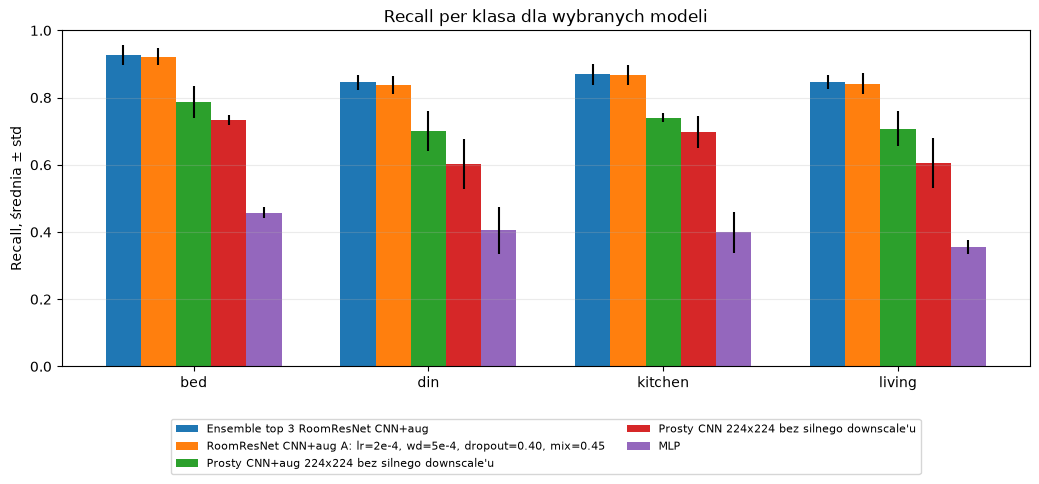

Saved per-class rows: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_per_class_metrics.csv
Saved per-class aggregate: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_per_class_aggregate.csv
Saved per-class recall plot: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/per_class_recall_comparison.png


In [11]:
per_class_rows = []
if seed_rows:
    for row in seed_rows:
        metrics_path = Path(row.get('metrics_path', ''))
        if not metrics_path.exists():
            continue
        metrics_json = json.loads(metrics_path.read_text())
        report = metrics_json.get('classification_report', {})
        for class_name in metrics_json.get('class_names', []):
            class_metrics = report.get(class_name, {})
            per_class_rows.append({
                'seed': row['seed'],
                'run': row['run'],
                'report_label': row['report_label'],
                'class_name': class_name,
                'precision': class_metrics.get('precision'),
                'recall': class_metrics.get('recall'),
                'f1_score': class_metrics.get('f1-score'),
                'support': class_metrics.get('support'),
            })

if per_class_rows:
    seeded_per_class = pd.DataFrame(per_class_rows)
    per_class_aggregate = (
        seeded_per_class
        .groupby(['report_label', 'class_name'], as_index=False)
        .agg(
            seeds=('seed', 'nunique'),
            precision_mean=('precision', 'mean'),
            precision_std=('precision', 'std'),
            recall_mean=('recall', 'mean'),
            recall_std=('recall', 'std'),
            f1_mean=('f1_score', 'mean'),
            f1_std=('f1_score', 'std'),
            support=('support', 'mean'),
        )
        .sort_values(['report_label', 'class_name'])
    )
    seeded_per_class_path = REPORT_DIR / 'seeded_per_class_metrics.csv'
    per_class_aggregate_path = REPORT_DIR / 'seeded_per_class_aggregate.csv'
    seeded_per_class.to_csv(seeded_per_class_path, index=False)
    per_class_aggregate.to_csv(per_class_aggregate_path, index=False)

    final_label = 'Ensemble top 3 RoomResNet CNN+aug'
    final_per_class = per_class_aggregate[per_class_aggregate['report_label'] == final_label].copy()
    display(final_per_class.round(4))

    selected_labels = [
        'Ensemble top 3 RoomResNet CNN+aug',
        'RoomResNet CNN+aug A: lr=2e-4, wd=5e-4, dropout=0.40, mix=0.45',
        "Prosty CNN+aug 224x224 bez silnego downscale'u",
        "Prosty CNN 224x224 bez silnego downscale'u",
        'MLP',
    ]
    recall_plot_frame = per_class_aggregate[per_class_aggregate['report_label'].isin(selected_labels)].copy()
    recall_plot_frame['report_label'] = pd.Categorical(recall_plot_frame['report_label'], selected_labels, ordered=True)

    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    x = np.arange(len(sorted(recall_plot_frame['class_name'].unique())))
    class_order = sorted(recall_plot_frame['class_name'].unique())
    width = 0.15
    for offset, label in enumerate(selected_labels):
        subset = recall_plot_frame[recall_plot_frame['report_label'] == label].set_index('class_name').reindex(class_order)
        ax.bar(x + (offset - 2) * width, subset['recall_mean'], width=width, yerr=subset['recall_std'].fillna(0), label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(class_order)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Recall, średnia ± std')
    ax.set_title('Recall per klasa dla wybranych modeli')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=8)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    per_class_recall_plot_path = REPORT_DIR / 'per_class_recall_comparison.png'
    report_per_class_recall_plot_path = REPORT_FIGURE_PATHS['per_class_recall_comparison']
    fig.savefig(per_class_recall_plot_path, dpi=180, bbox_inches='tight')
    fig.savefig(report_per_class_recall_plot_path, dpi=180, bbox_inches='tight')
    plt.show()

    print('Saved per-class rows:', seeded_per_class_path)
    print('Saved per-class aggregate:', per_class_aggregate_path)
    print('Saved per-class recall plot:', per_class_recall_plot_path)
    print('Saved report figure:', report_per_class_recall_plot_path)
else:
    print('Brak metryk per klasa dla seedowanych raportów.')


## 12. Krzywe treningu po seedach

Poniższy wykres zbiera historie treningowe zapisane przy seedowanych checkpointach. Linie pokazują średnie walidacyjne macro F1 i stratę po seedach, a półprzezroczysty obszar oznacza odchylenie standardowe. To pozwala odróżnić modele stabilne od takich, które silnie zależą od inicjalizacji i splitu.


,report_label,seeds,epochs_mean,epochs_std,best_val_macro_f1_mean,best_val_macro_f1_std,min_val_loss_mean,min_val_loss_std
8,"RoomResNet CNN+aug C: lr=2e-4, wd=5e-4, dropou...",5,315.6,68.7772,0.8713,0.0176,0.6330,0.0296
7,"RoomResNet CNN+aug B: lr=3e-4, wd=5e-4, dropou...",5,374.6,110.5613,0.8690,0.0151,0.6368,0.0259
6,"RoomResNet CNN+aug A: lr=2e-4, wd=5e-4, dropou...",5,287.8,61.9411,0.8669,0.0171,0.6396,0.0254
3,Prosty CNN+aug 224x224 bez silnego downscale'u,5,191.2,42.5347,0.7584,0.0120,0.7389,0.0214
1,Prosty CNN 224x224 bez silnego downscale'u,5,157.2,36.1068,0.6918,0.0169,0.9227,0.0115
4,Prosty CNN+aug 64x64 z downscalem,5,274.8,147.0228,0.6505,0.2480,0.8635,0.2895
2,Prosty CNN 64x64 z downscalem,5,122.8,27.5899,0.6496,0.0323,0.9500,0.0627
5,RoomResNet CNN bez augmentacji,5,127.2,9.5237,0.5717,0.0124,1.3769,0.0233
0,MLP,5,41.8,8.1670,0.4118,0.0077,1.3112,0.0117


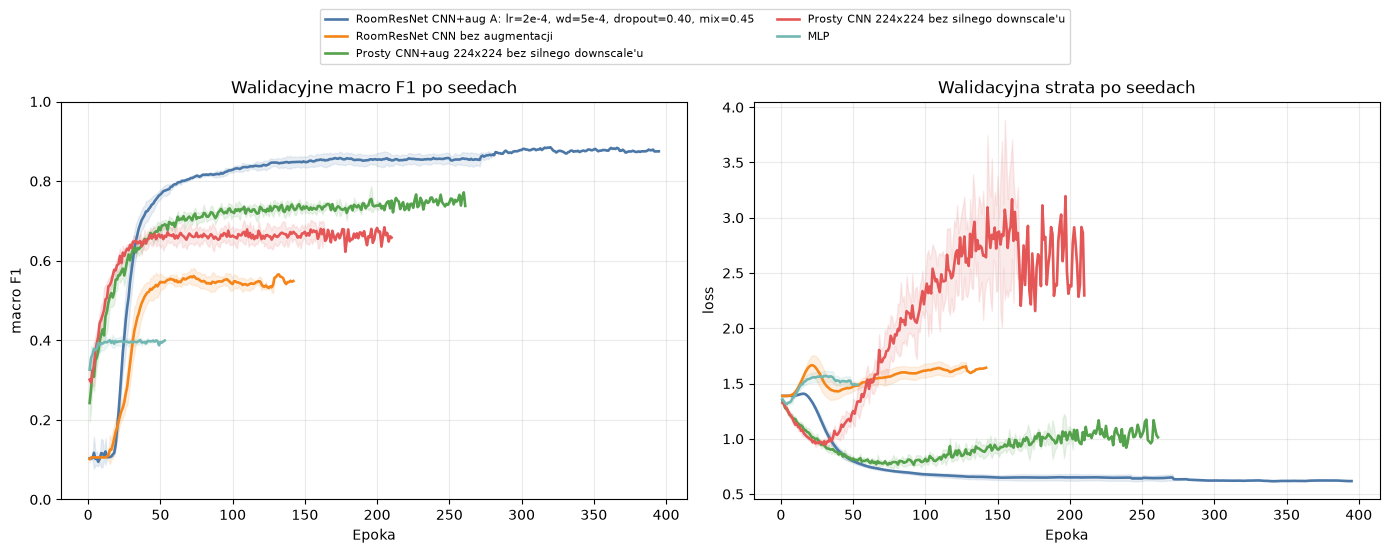

Saved seeded training summary: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_training_history_summary.csv
Saved seeded training aggregate: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/seeded_training_history_aggregate.csv
Saved training curves plot: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/training_curves_validation.png


In [12]:
seeded_history_rows = []
for history_path in sorted((ROOT / 'outputs' / 'checkpoints').glob('seeded_s*/*.history.csv')):
    run = history_path.parent.name
    match = re.match(r'seeded_s(\d+)_', run)
    if not match:
        continue
    frame = pd.read_csv(history_path)
    if frame.empty:
        continue
    frame['seed'] = int(match.group(1))
    frame['run'] = run
    frame['report_label'] = label_seeded_run(run)
    seeded_history_rows.append(frame)

if seeded_history_rows:
    seeded_history = pd.concat(seeded_history_rows, ignore_index=True)
    history_summary = (
        seeded_history
        .groupby(['report_label', 'seed'], as_index=False)
        .agg(
            epochs=('epoch', 'max'),
            best_val_macro_f1=('val_macro_f1', 'max'),
            best_val_accuracy=('val_accuracy', 'max'),
            min_val_loss=('val_loss', 'min'),
        )
        .sort_values(['report_label', 'seed'])
    )
    history_aggregate = (
        history_summary
        .groupby('report_label', as_index=False)
        .agg(
            seeds=('seed', 'nunique'),
            epochs_mean=('epochs', 'mean'),
            epochs_std=('epochs', 'std'),
            best_val_macro_f1_mean=('best_val_macro_f1', 'mean'),
            best_val_macro_f1_std=('best_val_macro_f1', 'std'),
            min_val_loss_mean=('min_val_loss', 'mean'),
            min_val_loss_std=('min_val_loss', 'std'),
        )
        .sort_values('best_val_macro_f1_mean', ascending=False)
    )
    display(history_aggregate.round(4))

    history_summary_path = REPORT_DIR / 'seeded_training_history_summary.csv'
    history_aggregate_path = REPORT_DIR / 'seeded_training_history_aggregate.csv'
    history_summary.to_csv(history_summary_path, index=False)
    history_aggregate.to_csv(history_aggregate_path, index=False)

    selected_training_labels = [
        'RoomResNet CNN+aug A: lr=2e-4, wd=5e-4, dropout=0.40, mix=0.45',
        'RoomResNet CNN bez augmentacji',
        "Prosty CNN+aug 224x224 bez silnego downscale'u",
        "Prosty CNN 224x224 bez silnego downscale'u",
        'MLP',
    ]
    plot_history = seeded_history[seeded_history['report_label'].isin(selected_training_labels)].copy()
    epoch_aggregate = (
        plot_history
        .groupby(['report_label', 'epoch'], as_index=False)
        .agg(
            val_macro_f1_mean=('val_macro_f1', 'mean'),
            val_macro_f1_std=('val_macro_f1', 'std'),
            val_loss_mean=('val_loss', 'mean'),
            val_loss_std=('val_loss', 'std'),
            seeds=('seed', 'nunique'),
        )
    )

    colors = {
        selected_training_labels[0]: '#4C78A8',
        selected_training_labels[1]: '#F58518',
        selected_training_labels[2]: '#54A24B',
        selected_training_labels[3]: '#E45756',
        selected_training_labels[4]: '#72B7B2',
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
    for label in selected_training_labels:
        subset = epoch_aggregate[epoch_aggregate['report_label'] == label].sort_values('epoch')
        if subset.empty:
            continue
        color = colors[label]
        axes[0].plot(subset['epoch'], subset['val_macro_f1_mean'], label=label, color=color, linewidth=1.9)
        axes[0].fill_between(
            subset['epoch'],
            subset['val_macro_f1_mean'] - subset['val_macro_f1_std'].fillna(0),
            subset['val_macro_f1_mean'] + subset['val_macro_f1_std'].fillna(0),
            color=color,
            alpha=0.12,
        )
        axes[1].plot(subset['epoch'], subset['val_loss_mean'], label=label, color=color, linewidth=1.9)
        axes[1].fill_between(
            subset['epoch'],
            subset['val_loss_mean'] - subset['val_loss_std'].fillna(0),
            subset['val_loss_mean'] + subset['val_loss_std'].fillna(0),
            color=color,
            alpha=0.12,
        )
    axes[0].set_title('Walidacyjne macro F1 po seedach')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('macro F1')
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.25)
    axes[1].set_title('Walidacyjna strata po seedach')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('loss')
    axes[1].grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2, fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, 0.88))
    seeded_training_plot_path = REPORT_DIR / 'training_curves_validation.png'
    report_seeded_training_plot_path = REPORT_FIGURE_PATHS['training_curves_validation']
    fig.savefig(seeded_training_plot_path, dpi=180, bbox_inches='tight')
    fig.savefig(report_seeded_training_plot_path, dpi=180, bbox_inches='tight')
    plt.show()

    print('Saved seeded training summary:', history_summary_path)
    print('Saved seeded training aggregate:', history_aggregate_path)
    print('Saved training curves plot:', seeded_training_plot_path)
    print('Saved report figure:', report_seeded_training_plot_path)
else:
    print('Brak historii treningu dla seedowanych checkpointów.')


## 13. Macierze pomyłek

Macierze pomyłek pokazują, które klasy są najczęściej mylone. Są szczególnie przydatne przy interpretacji różnic między modelem bez augmentacji, modelem z augmentacją i ensemble.


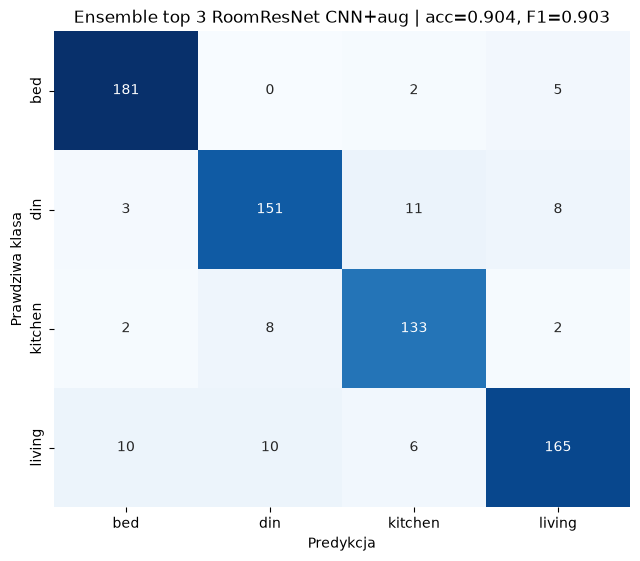

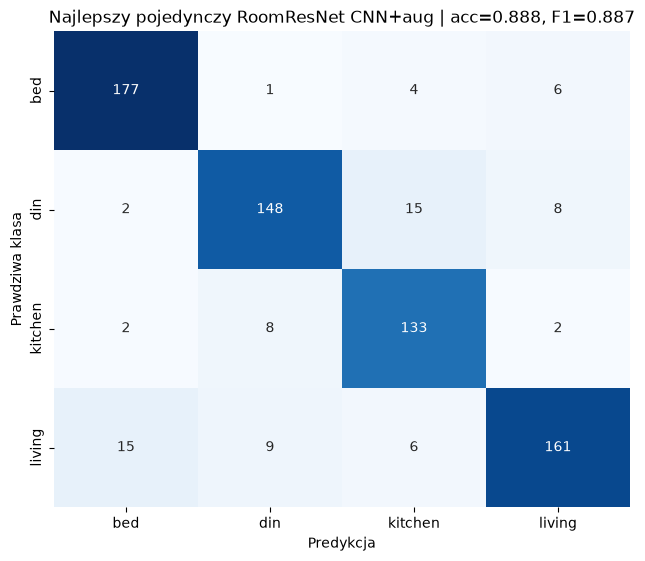

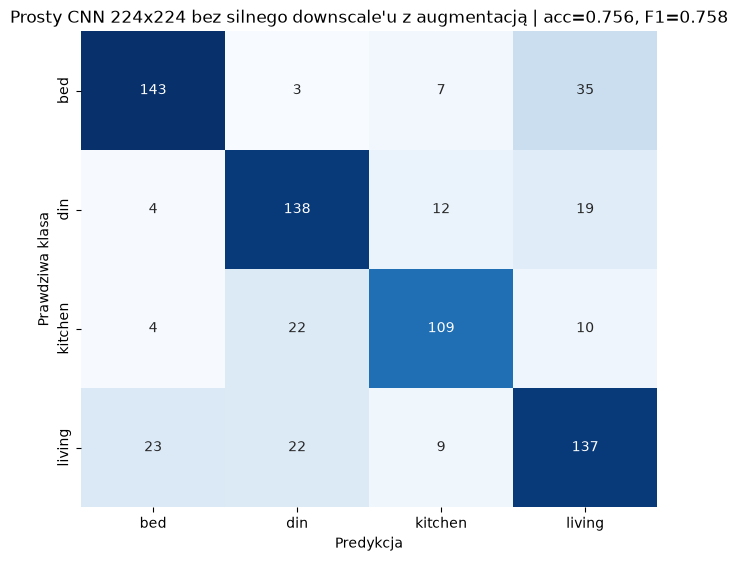

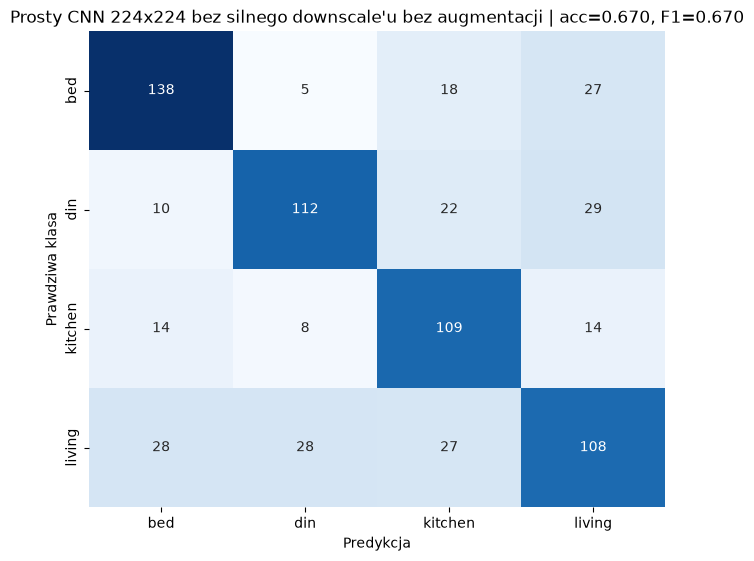

In [13]:
# Wykresy macierzy pomyłek wybieramy dla modeli najważniejszych w raporcie.
selected_for_plot = [
    'ensemble_top3_roomresnet_cnn_aug_tta5',
    'roomresnet_cnn_aug_rank1_large_256',
    'cnn_aug_224_no_downscale_wide',
    'cnn_224_no_downscale_deep',
]
metrics_by_name = {metrics['name']: metrics for metrics in individual_results + ensemble_results}

for name in selected_for_plot:
    metrics = metrics_by_name[name]
    fig, ax = plot_confusion_matrix(metrics['confusion_matrix'], metrics['class_names'])
    ax.set_title(f"{metrics['report_label']} | acc={metrics['accuracy']:.3f}, F1={metrics['macro_f1']:.3f}")
    plt.show()


## 14. Najtrudniejsze przykłady

Lista hard examples pokazuje próbki, na których najlepszy model radził sobie najsłabiej. To dobre miejsce do ręcznej kontroli etykiet, jakości zdjęć i typowych pomyłek modelu.


In [14]:
# Hard examples to próbki, dla których model miał największy błąd/niepewność predykcji.
hard_examples_path = REPORT_DIR / best_metrics['name'] / f"{best_metrics['name']}.test.hard_examples.csv"
if not hard_examples_path.exists():
    hard_examples_path = next((REPORT_DIR / best_metrics['name']).glob('*.hard_examples.csv'))

hard_examples = pd.read_csv(hard_examples_path)
display(hard_examples.head(20))


,path,label,true_idx,pred_idx,pred_label,pred_confidence,true_probability,confidence_margin,is_correct
0,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.914029,0.033319,0.880710,False
1,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,bed,0,2,kitchen,0.910873,0.028491,0.878046,False
2,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,living,3,2,kitchen,0.897443,0.020559,0.837296,False
3,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.888200,0.042353,0.845847,False
4,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,bed,0,2,kitchen,0.885786,0.038598,0.846682,False
5,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,2,kitchen,0.864992,0.075201,0.789791,False
6,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.864678,0.067405,0.797272,False
7,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,living,3,0,bed,0.864053,0.072431,0.791622,False
8,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,3,living,0.854609,0.046356,0.797478,False
9,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,3,living,0.845120,0.057333,0.787787,False


## 15. Zapisane artefakty

Ostatnia komórka wypisuje ścieżki do plików generowanych przez notebook: tabeli zbiorczej, raportu per klasa, podsumowania gridu i folderów z metrykami oraz macierzami pomyłek.


In [15]:
print('Saved summary:', SUMMARY_PATH)
print('Saved CNN scale grid summary:', GRID_SUMMARY_PATH)
print('Saved best per-class report:', PER_CLASS_PATH)
print('Saved per-model reports under:', REPORT_DIR)

# Kopia macierzy pomyłek używana w raporcie. Dzięki temu LaTeX nie zależy od głębokich ścieżek w outputs/.
confusion_matrix_candidates = [
    REPORT_DIR / 'ensemble_top3_roomresnet_cnn_aug_tta5' / 'ensemble_top3_roomresnet_cnn_aug_tta5.test.confusion_matrix.png',
    ROOT / 'outputs' / 'reports' / 'seeded_s42_ensemble_top3_roomresnet_aug_tta5' / 'seeded_s42_ensemble_top3_roomresnet_aug_tta5.test.confusion_matrix.png',
]
for source_path in confusion_matrix_candidates:
    if source_path.exists():
        final_confusion_path = REPORT_FIGURE_PATHS['final_ensemble_confusion_matrix']
        shutil.copy2(source_path, final_confusion_path)
        print('Saved final confusion matrix figure:', final_confusion_path)
        break
else:
    print('Brak macierzy pomyłek ensemble do skopiowania do figures/.')



Saved summary: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/summary_test.csv
Saved CNN scale grid summary: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/cnn_scale_grid_summary.csv
Saved best per-class report: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/best_model_classification_report.csv
Saved per-model reports under: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval
